In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import torch

In [3]:
# Data preparation for all models

columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"]
df = pd.read_csv("nsl-kdd/KDDTrain+_20Percent.txt", header=None, names = columns)

In [4]:
y = (df["label"] != "normal").astype(int).values
# y
x = df.drop(columns=["label", "difficulty"])
x = pd.get_dummies(x, columns=["protocol_type", "service", "flag"])
# x

In [5]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(x)
# X_scaled

In [6]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Final shape {X_pca.shape}")

Final shape (25192, 84)


In [7]:
num_nodes = len(X_pca)
indices = np.random.permutation(num_nodes)

In [8]:
train_size = int(0.7 * num_nodes)
val_size = int(0.15 * num_nodes)

In [9]:
train_mask = np.zeros(num_nodes, dtype=bool)
test_mask = np.zeros(num_nodes, dtype=bool)
val_mask = np.zeros(num_nodes, dtype=bool)

In [10]:
train_mask[indices[:train_size]] = True
test_mask[indices[train_size: train_size + val_size]] = True
val_mask[indices[train_size+val_size:]] = True

In [11]:
X_train, y_train = X_pca[train_mask], y[train_mask]
X_test, y_test = X_pca[test_mask], y[test_mask]
X_val, y_val = X_pca[val_mask], y[val_mask]

In [43]:
def evaluate_and_plot(y_true, y_pred, model, configs):
    print(f"{'-'*100}")
    print(f"Model: {model}")
    print(f"Hyper Parameters: {configs}" )
    print(f"{'-'*100}")

    print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

    config_str = "-".join([f"{k}_{v}" for k, v in configs.items()])
    filename = f"results/{model}_{config_str}_CM.png"

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Attack'], 
                yticklabels=['Normal', 'Attack'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"{model} Confusion Matrix")
    plt.savefig(filename)

    plt.show()
    plt.close()

SVM Model
----------------------------------------------------------------------------------------------------
Model: SVM
Hyper Parameters: {'kernel': 'linear', 'C': 10, 'class_weight': 'balanced'}
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      2016
      Attack       0.98      0.96      0.97      1762

    accuracy                           0.97      3778
   macro avg       0.98      0.97      0.97      3778
weighted avg       0.98      0.97      0.97      3778



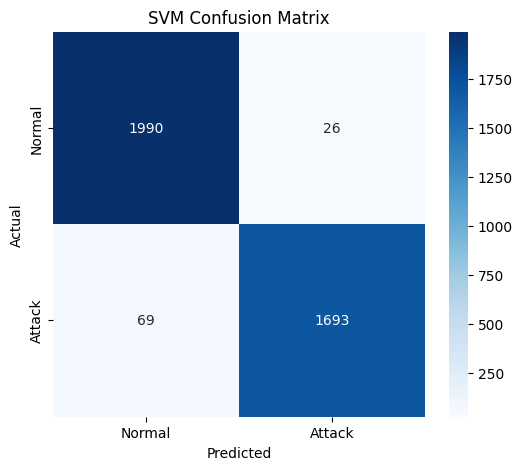

In [ ]:
from sklearn.svm import SVC

svm_config = {
    'kernel': 'linear', 
    'C': 10, #Regularization param
    'class_weight': 'balanced' # adjusts weights inversely proportional to class frequencies
}

print("SVM Model")
svm_model = SVC(
    kernel=svm_config['kernel'],
    C=svm_config['C'],
    class_weight=svm_config['class_weight'],
    random_state=42
)

svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
evaluate_and_plot(y_test, svm_preds, "SVM", svm_config)

----------------------------------------------------------------------------------------------------
Model: GAT
Hyper Parameters: {'k_neighbors': 3, 'heads': 4, 'hidden_dim': 64, 'lr': 0.005, 'threshold': 0.35}
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      2016
      Attack       0.96      1.00      0.98      1762

    accuracy                           0.98      3778
   macro avg       0.98      0.98      0.98      3778
weighted avg       0.98      0.98      0.98      3778



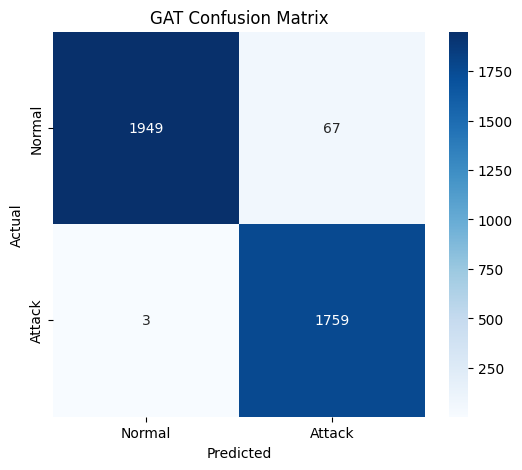

In [ ]:
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from sklearn.neighbors import NearestNeighbors

gat_configs = {
    'k_neighbors': 3,
    'heads': 4,
    'hidden_dim': 64,
    'lr': 0.005,
    'threshold': 0.35
}

nn = NearestNeighbors(n_neighbors=gat_configs['k_neighbors'] + 1, metric='euclidean')
nn.fit(X_pca)
_, indices = nn.kneighbors(X_pca)
neighbors = indices[:, 1: ]

sources = np.repeat(np.arange(len(X_pca)), gat_configs['k_neighbors'])
targets = neighbors.flatten()

data = Data(
    x=torch.tensor(X_pca, dtype=torch.float),
    edge_index=torch.tensor(np.vstack((sources, targets)), dtype=torch.long),
    y=torch.tensor(y, dtype=torch.long)
)

data.train_mask = torch.tensor(train_mask, dtype=torch.bool)
data.val_mask = torch.tensor(val_mask, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask, dtype=torch.bool)

class GATClassifier(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, heads):
        super().__init__()
        head_dim = hidden_dim // heads
        self.gat1 = GATConv(input_dim, head_dim, heads=heads)
        self.gat2 = GATConv(hidden_dim, head_dim, heads=heads)
        self.classifier = torch.nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)

        x = F.relu(self.gat2(x, edge_index))

        return F.log_softmax(self.classifier(x), dim=1)
    

model = GATClassifier(X_pca.shape[1], gat_configs['hidtden_dim'], gat_configs['heads'])

optimizer = torch.optim.Adam(model.parameters(), lr=gat_configs['lr'], weight_decay=5e-4)
class_weights = torch.tensor([1.0, 5.0], dtype=torch.float) #To change weights of classes, inc "Attack" class weights

model.train()
epochs = 150
for epoch in range(epochs): 
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    probs = torch.exp(model(data))[:, 1]
    gat_preds_tensor = (probs >= gat_configs['threshold']).int()

gat_preds = gat_preds_tensor[data.test_mask].cpu().numpy()

evaluate_and_plot(y_test, gat_preds, "GAT", gat_configs)

----------------------------------------------------------------------------------------------------
Model: LogisticRegression
Hyper Parameters: {'C': 10, 'max_iter': 5000, 'weight': 'balanced'}
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      2016
      Attack       0.98      0.96      0.97      1762

    accuracy                           0.97      3778
   macro avg       0.97      0.97      0.97      3778
weighted avg       0.97      0.97      0.97      3778



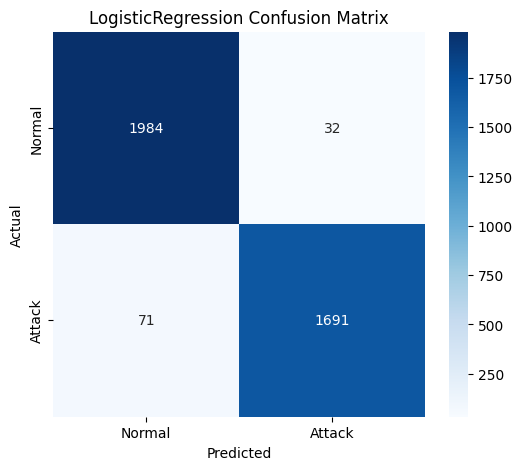

In [89]:
from sklearn.linear_model import LogisticRegression

LogisticRegression_config = {
    'C': 10,
    'max_iter': 5000,
    'weight' : 'balanced',
}

model = LogisticRegression(
    C = LogisticRegression_config['C'],
    max_iter = LogisticRegression_config['max_iter'],
    class_weight = LogisticRegression_config['weight'],
    random_state = 42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

evaluate_and_plot(y_test, preds, "LogisticRegression", LogisticRegression_config)

----------------------------------------------------------------------------------------------------
Model: RandomForest
Hyper Parameters: {'estimators': 100, 'depth': 12, 'weight': 'balanced'}
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2016
      Attack       1.00      0.99      1.00      1762

    accuracy                           1.00      3778
   macro avg       1.00      1.00      1.00      3778
weighted avg       1.00      1.00      1.00      3778



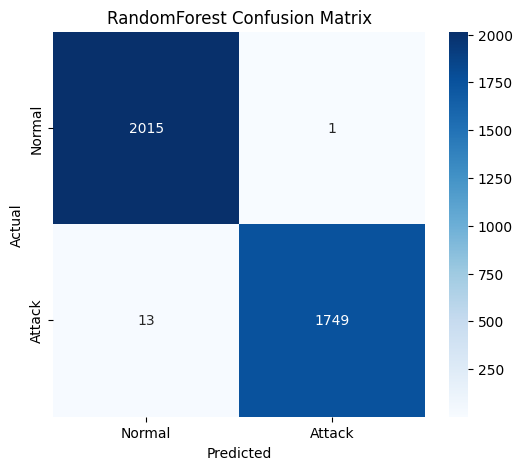

In [105]:
from sklearn.ensemble import RandomForestClassifier

config = {
    'estimators': 100,
    'depth': 12,          
    # 'weight': {0:1, 1:20}
    'weight': 'balanced'
}

model = RandomForestClassifier(
    n_estimators=config['estimators'],
    max_depth=config['depth'],
    class_weight=config['weight'],
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

evaluate_and_plot(y_test, preds, "RandomForest", config)

----------------------------------------------------------------------------------------------------
Model: MLP
Hyper Parameters: {'hidden_layers': (128, 64, 32), 'activation': 'relu', 'lr': 0.001, 'max_iter': 300}
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2016
      Attack       1.00      0.99      1.00      1762

    accuracy                           1.00      3778
   macro avg       1.00      1.00      1.00      3778
weighted avg       1.00      1.00      1.00      3778



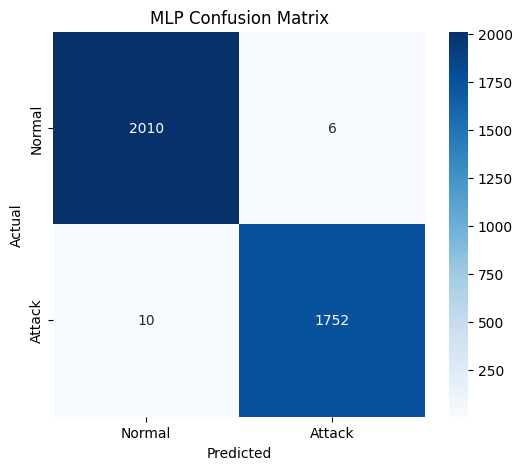

In [107]:
from sklearn.neural_network import MLPClassifier

MLP_config = {
    'hidden_layers': (128, 64, 32),
    'activation': 'relu',
    'lr': 0.001,
    'max_iter': 300
}

model = MLPClassifier(
    hidden_layer_sizes=MLP_config['hidden_layers'],
    activation=MLP_config['activation'],
    learning_rate_init=MLP_config['lr'],
    max_iter=MLP_config['max_iter'],
    n_jobs = -1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

evaluate_and_plot(y_test, preds, "MLP", MLP_config)